# Chapter 5 Hands-On: Dynamic Positioning Simulation with Environmental Disturbances

This notebook provides a teaching-oriented implementation of a simplified dynamic-positioning simulation. The workflow combines vessel dynamics, wind and wave disturbances, thruster force allocation, PID control, and power estimation. The example is intended for learning the structure of a simulation model rather than reproducing a certified ship-motion simulator.

## Step 1. Import libraries and define helper functions

This step imports the numerical and plotting libraries used throughout the simulation. It also defines three helper functions. The ssa function wraps angular errors into a standard interval, Rzyx constructs the yaw rotation matrix, and invQR provides a numerically stable inverse for matrices used in control allocation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

# ==========================================
# 1. Helper Functions (Math & Geometry)
# ==========================================

def ssa(angle, unit='rad'):
    """Maps an angle to [-pi, pi) or [-180, 180)."""
    if unit == 'rad':
        return (angle + np.pi) % (2 * np.pi) - np.pi
    elif unit == 'deg':
        return (angle + 180) % 360 - 180
    else:
        raise ValueError("Unit must be 'rad' or 'deg'")

def Rzyx(phi, theta, psi):
    """Euler angle rotation matrix R in SO(3) using zyx convention."""
    cphi = np.cos(phi)
    sphi = np.sin(phi)
    cth  = np.cos(theta)
    sth  = np.sin(theta)
    cpsi = np.cos(psi)
    spsi = np.sin(psi)
    
    R = np.array([
        [cpsi*cth, -spsi*cphi + cpsi*sth*sphi, spsi*sphi + cpsi*cphi*sth],
        [spsi*cth,  cpsi*cphi + sphi*sth*spsi, -cpsi*sphi + sth*spsi*cphi],
        [-sth,      cth*sphi,                  cth*cphi]
    ])
    return R

def invQR(A):
    """Computes inverse using QR decomposition for numerical stability."""
    n = A.shape[0]
    if np.linalg.matrix_rank(A) < n:
        raise ValueError('The matrix is near-singular and not invertible.')
    Q, R, p_indices = scipy.linalg.qr(A, pivoting=True)
    P = np.eye(n)[:, p_indices]
    temp = scipy.linalg.solve_triangular(R, Q.T)
    Ainv = P @ temp
    return Ainv


## Step 2. Construct the environmental disturbance model

This step defines a simplified environmental model that combines wind and wave loads. The wave component is generated from a JONSWAP spectrum, while the wind component uses direction-dependent coefficients to produce surge force, sway force, and yaw moment in the vessel body frame.

In [2]:
# ==========================================
# 2. Environmental Disturbance Class
# ==========================================

class EnvironmentalDisturbance:
    """
    Simulates Wind and Wave forces using JONSWAP spectrum and Wind coefficients.
    """
    def __init__(self, Hs, Tp, beta_wave, V_wind, beta_wind, L, seed=42):
        """
        Args:
            L: Ship Length (m) - Critical for Moment calculation
        """
        self.Hs = Hs
        self.Tp = Tp
        self.beta_wave = beta_wave
        self.V_wind = V_wind
        self.beta_wind = beta_wind
        self.L = L 
        
        # Wind Coefficients (Simplified)
        self.rho_air = 1.225
        self.A_frontal = 400.0 
        self.A_lateral = 800.0 
        
        # JONSWAP Setup
        np.random.seed(seed)
        self.n_freq = 100 
        self.w_min = 0.1
        self.w_max = 3.0
        self.dw = (self.w_max - self.w_min) / self.n_freq
        self.w = np.linspace(self.w_min, self.w_max, self.n_freq)
        
        # Generate Spectrum and Amplitudes
        self.S_jonswap = self._compute_jonswap(self.w, Hs, Tp)
        self.wave_amps = np.sqrt(2 * self.S_jonswap * self.dw)
        self.phases = np.random.rand(self.n_freq) * 2 * np.pi
        
        # Force Transfer Function Approximation
        self.force_scale = np.array([50e3, 50e3, 50e5]) 

    def _compute_jonswap(self, w, Hs, Tp):
        wp = 2 * np.pi / Tp
        gamma = 3.3
        sigma = np.where(w <= wp, 0.07, 0.09)
        S_pm = (5/16) * (Hs**2 * wp**4) * (w**-5) * np.exp(-1.25 * (w/wp)**-4)
        r = np.exp(-(w - wp)**2 / (2 * sigma**2 * wp**2))
        S = S_pm * (gamma ** r)
        return S

    def get_wave_force(self, t):
        wave_oscillation = np.sum(self.wave_amps * np.cos(self.w * t + self.phases))
        F_surge = self.force_scale[0] * wave_oscillation * np.cos(self.beta_wave)
        F_sway  = self.force_scale[1] * wave_oscillation * np.sin(self.beta_wave)
        M_yaw   = self.force_scale[2] * wave_oscillation * 0.1 * np.sin(2*self.beta_wave) 
        return np.array([F_surge, F_sway, M_yaw])

    def get_wind_force(self, eta):
        psi = eta[2]
        gamma_w = ssa(self.beta_wind - psi)
        Cx = -0.8 * np.cos(gamma_w) 
        Cy = 0.8 * np.sin(gamma_w)
        Cn = 0.1 * np.sin(2 * gamma_w) 
        
        F_x = 0.5 * self.rho_air * self.A_frontal * (self.V_wind**2) * Cx
        F_y = 0.5 * self.rho_air * self.A_lateral * (self.V_wind**2) * Cy
        M_n = 0.5 * self.rho_air * self.A_lateral * self.L * (self.V_wind**2) * Cn 
        return np.array([F_x, F_y, M_n])

    def get_total_force(self, t, eta):
        tau_wind = self.get_wind_force(eta)
        tau_wave_global = self.get_wave_force(t)
        
        # Rotate global wave forces to body frame
        psi = eta[2]
        R_trans = np.array([
            [np.cos(psi), np.sin(psi), 0],
            [-np.sin(psi), np.cos(psi), 0],
            [0,            0,           1]
        ])
        tau_wave_body = R_trans @ tau_wave_global
        return tau_wind + tau_wave_body


## Step 3. Define the supply vessel dynamics

This step implements a three-degree-of-freedom vessel model in surge, sway, and yaw. The class stores the inertia and damping matrices and evaluates the state derivatives from the current position, relative velocity, and total applied force.

In [3]:
# ==========================================
# 3. Vessel Dynamics Class
# ==========================================

class SupplyVessel:
    def __init__(self):
        self.L    = 76.2
        self.g    = 9.81
        self.mass = 6000e3
        self._init_matrices()

    def _init_matrices(self):
        T    = np.diag([1, 1, 1/self.L])
        Tinv = np.diag([1, 1, self.L])
        Mbis = np.array([
            [1.1274, 0, 0], [0, 1.8902, -0.0744], [0, -0.0744, 0.1278]
        ])
        Dbis = np.array([
            [0.0358, 0, 0], [0, 0.1183, -0.0124], [0, -0.0041, 0.0308]
        ])
        self.M = self.mass * (Tinv @ Tinv) @ (T @ Mbis @ Tinv)
        self.D = self.mass * (Tinv @ Tinv) @ (np.sqrt(self.g/self.L) * T @ Dbis @ Tinv)
        self.Minv = np.linalg.inv(self.M)

    def get_derivatives(self, eta, nu_r, tau):
        eta = eta.reshape(-1, 1)
        nu_r = nu_r.reshape(-1, 1)
        tau = tau.reshape(-1, 1)
        
        psi = eta[2, 0]
        R_yaw = np.array([
            [np.cos(psi), -np.sin(psi), 0],
            [np.sin(psi),  np.cos(psi), 0],
            [0,            0,           1]
        ])
        
        damping_force = self.D @ nu_r
        nu_dot = self.Minv @ (tau - damping_force)
        
        A_top = np.hstack((np.zeros((3,3)), R_yaw))
        A_bot = np.hstack((np.zeros((3,3)), -self.Minv @ self.D))
        A = np.vstack((A_top, A_bot))
        B = np.vstack((np.zeros((3,3)), self.Minv))
        
        x = np.vstack((eta, nu_r))
        xdot = A @ x + B @ tau
        return xdot.flatten()


## Step 4. Define the thruster system and power model

This step builds the thruster configuration matrix for four tunnel thrusters and two main propellers. It also includes propeller saturation, thrust generation, and a cubic power-consumption model based on the commanded propeller revolutions.

In [4]:
# ==========================================
# 4. Thruster System Class
# ==========================================

class ThrusterSystem:
    def __init__(self):
        self.L = 76.2
        self.T_n = 1.0 
        self.n_max = np.array([250, 250, 250, 250, 160, 160]) # RPM
        self.K_thr = np.diag([3.2, 3.2, 3.2, 3.2, 31.2, 31.2])
        self.W = np.diag([1, 1, 1, 1, 1, 1]) 
        
        # --- Power Estimation Parameters ---
        # Assumed Max Power (Watts) for Coefficient Calculation
        # Tunnel: 600kW, Main: 3000kW
        self.P_max_watts = np.array([600e3, 600e3, 600e3, 600e3, 3000e3, 3000e3])
        # k_p = P_max / n_max^3
        self.k_p = self.P_max_watts / (self.n_max ** 3)

        # Configuration
        self.types = ['T', 'T', 'T', 'T', 'M', 'M']
        self.lx = [30, 22, -22, -30, -self.L/2, -self.L/2]
        self.ly = [0, 0, 0, 0, 8, -8]
        self.T_matrix = self._compute_config_matrix()

    def _compute_config_matrix(self):
        m = len(self.types)
        T_thr = np.zeros((3, m))
        for i in range(m):
            val = self.types[i]
            if val == 'M': 
                T_thr[:, i] = [1, 0, -self.ly[i]]
            elif val == 'T': 
                T_thr[:, i] = [0, 1, self.lx[i]]
            else: 
                az = float(val)
                T_thr[:, i] = [np.cos(az), np.sin(az), self.lx[i]*np.sin(az) - self.ly[i]*np.cos(az)]
        return T_thr

    def saturate(self, n_prop):
        n_prop_sat = n_prop.copy()
        for j in range(6):
            if abs(n_prop_sat[j]) > self.n_max[j]:
                n_prop_sat[j] = np.sign(n_prop_sat[j]) * self.n_max[j]
        return n_prop_sat

    def get_force(self, n_prop):
        u_thr = np.abs(n_prop) * n_prop
        u_thr = u_thr.reshape(-1, 1)
        tau = self.T_matrix @ self.K_thr @ u_thr
        return tau.flatten()

    def get_power(self, n_prop):
        """Calculates total power consumption in Watts based on cubic law."""
        powers = self.k_p * (np.abs(n_prop) ** 3)
        return np.sum(powers)


## Step 5. Implement control allocation and PID control

This step converts the desired generalized control force into individual thruster commands using a weighted pseudoinverse allocation method. A PID controller is then used to drive the vessel toward the target north position, east position, and heading.

In [5]:
# ==========================================
# 5. Control Allocation & PID
# ==========================================

def allocPseudoinverse(K, T, W, tau):
    tau = tau.reshape(-1, 1) 
    if np.linalg.det(W) == 0 or not np.allclose(W, np.diag(np.diag(W))):
        raise ValueError("W must be a positive diagonal matrix")
    if np.linalg.det(K) == 0 or not np.allclose(K, np.diag(np.diag(K))):
        raise ValueError("K must be a positive diagonal matrix")
    Winv = np.diag(1.0 / np.diag(W))
    Kinv = np.diag(1.0 / np.diag(K))
    term = T @ Winv @ T.T
    inv_term = invQR(term)
    u = Kinv @ Winv @ T.T @ inv_term @ tau
    return u.flatten()

class PIDController:
    def __init__(self):
        self.z_int = np.zeros(3) 
        self.eta_d = np.zeros(3) 
        
    def update(self, eta, nu, eta_ref, M, wn, zeta, T_f, h):
        eta = eta.reshape(-1, 1)
        nu = nu.reshape(-1, 1)
        eta_ref = eta_ref.reshape(-1, 1)
        self.z_int = self.z_int.reshape(-1, 1)
        self.eta_d = self.eta_d.reshape(-1, 1)
        
        psi = eta[2, 0]
        R = np.array([
            [np.cos(psi), -np.sin(psi), 0],
            [np.sin(psi),  np.cos(psi), 0],
            [0,            0,           1]
        ])
        
        M_diag = np.diag(np.diag(M))
        Kp = M_diag @ (wn @ wn)
        Kd = M_diag @ (2 * zeta @ wn)
        Ki = 0.1 * Kp @ wn
        
        e = eta - self.eta_d
        e[2, 0] = ssa(e[2, 0]) 
        
        tau_PID = -R.T @ (Kp @ e + Ki @ self.z_int) - Kd @ nu
        
        self.z_int = self.z_int + h * (eta - self.eta_d)
        self.eta_d = self.eta_d + h * (eta_ref - self.eta_d) / T_f
        
        return tau_PID.flatten()


## Step 6. Run the dynamic-positioning simulation and plot responses

This step integrates the complete simulation. It instantiates the vessel, thruster, controller, and environmental models, applies current, wind, and wave disturbances, computes control commands and power consumption, updates vessel motion, and plots trajectory, disturbance, heading, speed, power, and thruster responses.

Starting Simulation with Environment & Power Calc...
Simulation Complete.


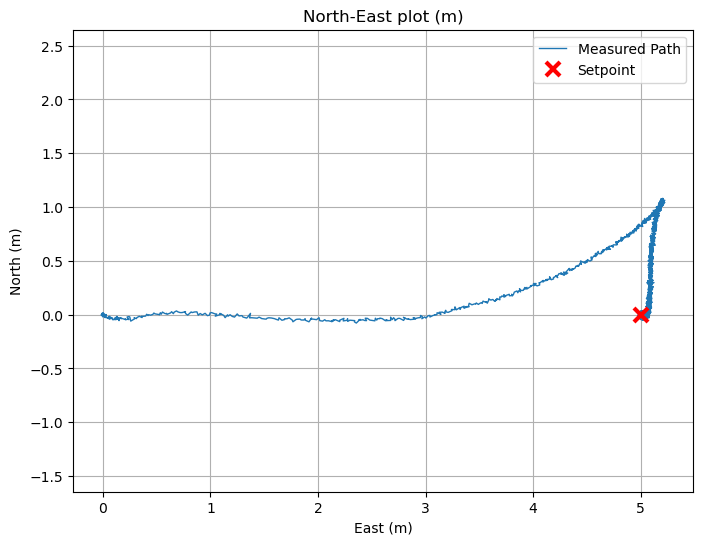

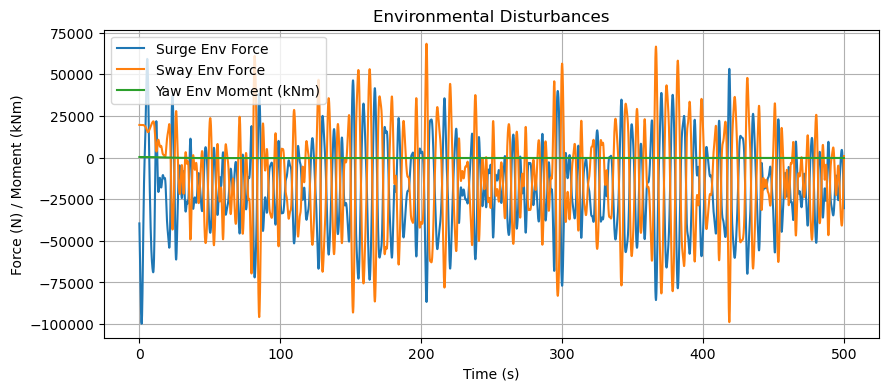

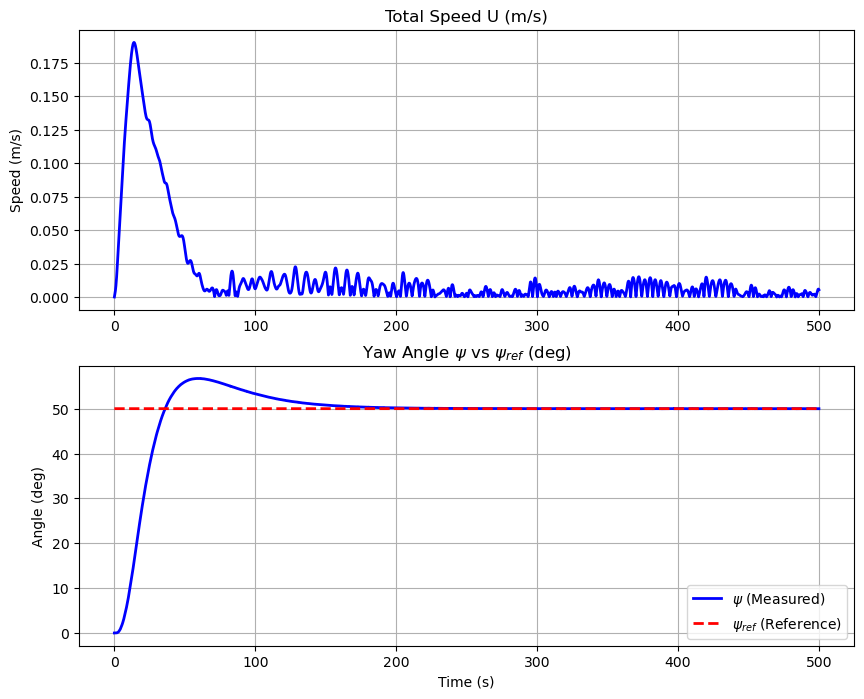

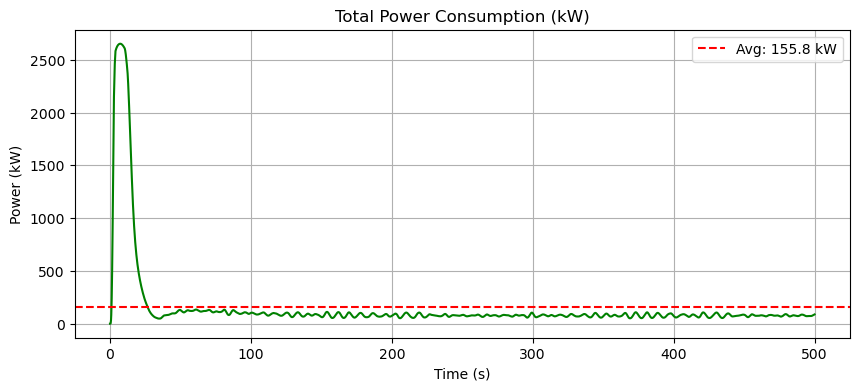

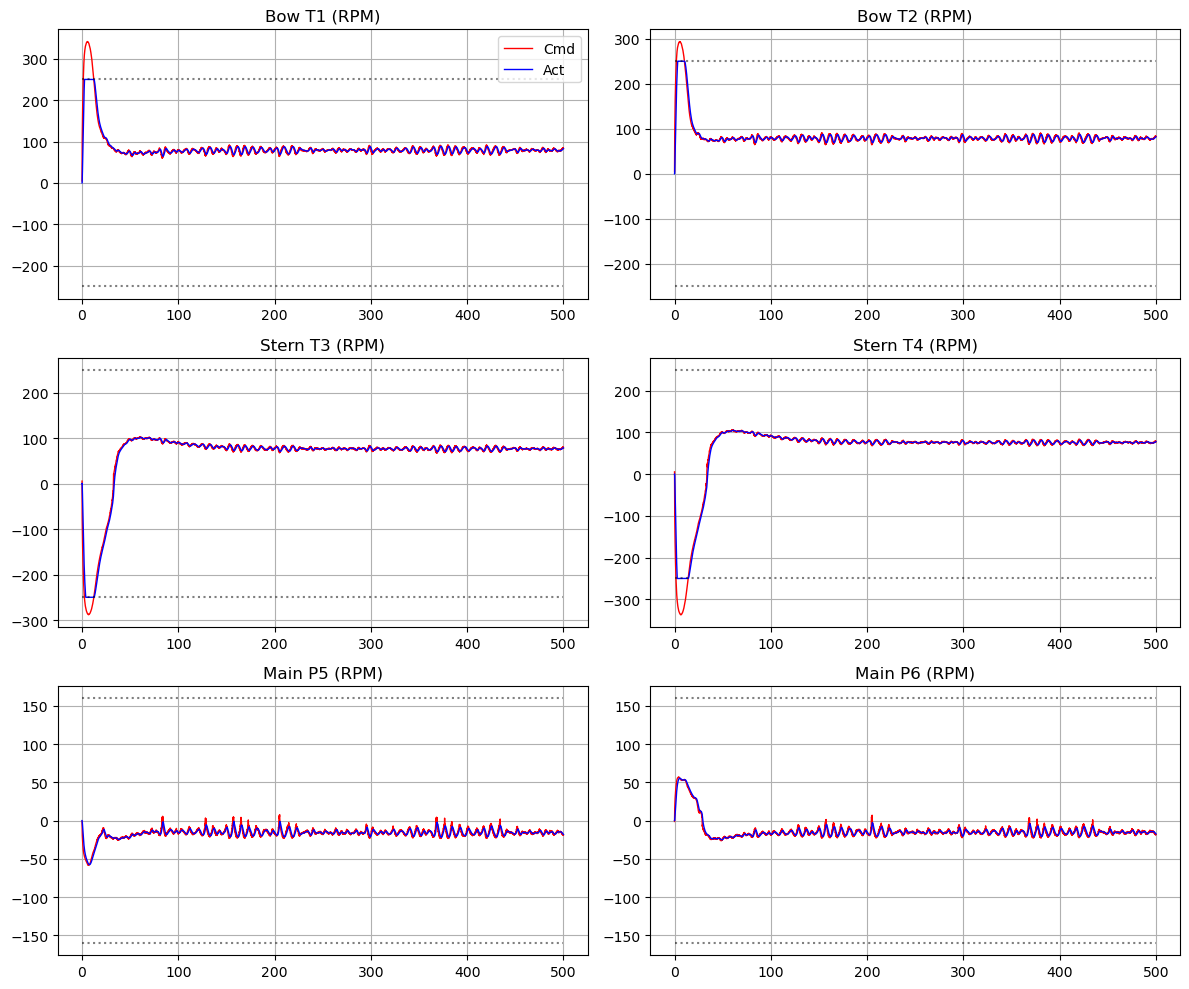

In [6]:
# ==========================================
# 6. Main Simulation Script
# ==========================================

def main():
    # Simulation Parameters
    T_final = 500
    h = 0.1
    t = np.arange(0, T_final + h, h)
    nTimeSteps = len(t)
    
    # --- INSTANTIATE CLASSES ---
    vessel = SupplyVessel()      
    thrusters = ThrusterSystem() 
    pid = PIDController()        
    
    # Environment Setup
    # Note: Passing vessel.L to Environment for correct Moment calc
    env = EnvironmentalDisturbance(
        Hs=2.5, Tp=8.0, beta_wave=0.0,   
        V_wind=10.0, beta_wind=np.deg2rad(30),
        L=vessel.L 
    )

    Vc = 0.5
    betaVc = np.deg2rad(20)
    
    # DP Control Settings
    psi_ref_deg = 50
    psi_ref = np.deg2rad(psi_ref_deg)
    eta_ref = np.array([0, 5, psi_ref]) # Target: N=0, E=5, Psi=50deg
    wn = np.diag([0.1, 0.1, 0.2])
    zeta = np.diag([1.0, 1.0, 1.0])
    T_f_const = 10.0
    
    # Initial States
    eta = np.zeros(3) 
    nu = np.zeros(3)  
    n_prop = np.zeros(6) 
    
    # Data Logging
    # [nu(3), eta_meas(3), n(6), n_c(6), tau_env(3), U(1), psi_ref(1), Power(1)]
    # 3+3+6+6+3+1+1+1 = 24 columns
    simdata = np.zeros((nTimeSteps, 24)) 
    
    print("Starting Simulation with Environment & Power Calc...")
    
    for i in range(nTimeSteps):
        current_time = t[i]

        # 1. Measurement (Sensor Model)
        eta_meas = eta.copy()
        eta_meas[0] += 0.01 * np.random.randn()
        eta_meas[1] += 0.01 * np.random.randn()
        eta_meas[2] += 0.0001 * np.random.randn()
        
        # 2. Environment Forces
        tau_env = env.get_total_force(current_time, eta)
        
        # 3. Current velocities
        u_c = Vc * np.cos(betaVc - eta[2])
        v_c = Vc * np.sin(betaVc - eta[2])
        nu_r = nu - np.array([u_c, v_c, 0]) 
        
        # 4. PID Control
        tau_PID = pid.update(eta_meas, nu, eta_ref, vessel.M, wn, zeta, T_f_const, h)
        
        # 5. Control Allocation
        u_alloc = allocPseudoinverse(thrusters.K_thr, thrusters.T_matrix, thrusters.W, tau_PID)
        n_c = np.sign(u_alloc) * np.sqrt(np.abs(u_alloc))
        
        # 6. Propeller Dynamics & Saturation
        n_prop = thrusters.saturate(n_prop)
        
        # --- POWER CALCULATION ---
        power_watts = thrusters.get_power(n_prop)
        
        # 7. Actual Force & Dynamics
        tau_thruster = thrusters.get_force(n_prop)
        tau_total = tau_thruster + tau_env
        xdot = vessel.get_derivatives(eta, nu_r, tau_total)
        ndot = (n_c - n_prop) / thrusters.T_n
        
        # Calculate Total Speed U
        U_current = np.sqrt(nu[0]**2 + nu[1]**2)

        # 8. Store Data
        simdata[i, 0:3] = nu
        simdata[i, 3:6] = eta_meas 
        simdata[i, 6:12] = n_prop
        simdata[i, 12:18] = n_c
        simdata[i, 18:21] = tau_env 
        simdata[i, 21] = U_current 
        simdata[i, 22] = eta_ref[2]
        simdata[i, 23] = power_watts 

        # 9. Integration
        nu = nu + h * xdot[3:6]
        R_mat = Rzyx(0, 0, eta[2])
        eta = eta + h * (R_mat @ nu)
        n_prop = n_prop + h * ndot

    print("Simulation Complete.")
    
    # ==========================================
    # 7. Plotting
    # ==========================================
    # Extract data
    x_meas_plt = simdata[:, 3]
    y_meas_plt = simdata[:, 4]
    psi_meas_plt = np.rad2deg(simdata[:, 5])
    
    n_plt = simdata[:, 6:12]
    nc_plt = simdata[:, 12:18]
    tau_env_plt = simdata[:, 18:21]
    
    U_plt = simdata[:, 21]
    psi_ref_plt = np.rad2deg(simdata[:, 22])
    
    Power_plt_kW = simdata[:, 23] / 1000.0 # Convert to kW
    
    # --- Figure 1: Position Trajectory ---
    plt.figure(figsize=(8, 6))
    plt.plot(y_meas_plt, x_meas_plt, linewidth=1, label='Measured Path')
    plt.plot(eta_ref[1], eta_ref[0], 'rx', markersize=10, markeredgewidth=3, label='Setpoint')
    plt.title('North-East plot (m)')
    plt.xlabel('East (m)')
    plt.ylabel('North (m)')
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    
    # --- Figure 2: Environmental Forces ---
    plt.figure(figsize=(10, 4))
    plt.plot(t, tau_env_plt[:, 0], label='Surge Env Force')
    plt.plot(t, tau_env_plt[:, 1], label='Sway Env Force')
    plt.plot(t, tau_env_plt[:, 2]/1000, label='Yaw Env Moment (kNm)')
    plt.title('Environmental Disturbances')
    plt.xlabel('Time (s)')
    plt.ylabel('Force (N) / Moment (kNm)')
    plt.grid(True)
    plt.legend()

    # --- Figure 3: Speed & Heading ---
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(t, U_plt, linewidth=2, color='b')
    plt.title('Total Speed U (m/s)')
    plt.ylabel('Speed (m/s)')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t, psi_meas_plt, linewidth=2, label=r'$\psi$ (Measured)', color='b')
    plt.plot(t, psi_ref_plt, 'r--', linewidth=2, label=r'$\psi_{ref}$ (Reference)')
    plt.title(r'Yaw Angle $\psi$ vs $\psi_{ref}$ (deg)')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (deg)')
    plt.grid(True)
    plt.legend()

    # --- Figure 4: Power Consumption ---
    plt.figure(figsize=(10, 4))
    plt.plot(t, Power_plt_kW, 'g-', linewidth=1.5)
    avg_power = np.mean(Power_plt_kW)
    plt.axhline(y=avg_power, color='r', linestyle='--', label=f'Avg: {avg_power:.1f} kW')
    plt.title('Total Power Consumption (kW)')
    plt.xlabel('Time (s)')
    plt.ylabel('Power (kW)')
    plt.grid(True)
    plt.legend()
    
    # --- Figure 5: Thruster RPMs ---
    titles = ['Bow T1', 'Bow T2', 'Stern T3', 'Stern T4', 'Main P5', 'Main P6']
    plt.figure(figsize=(12, 10))
    for k in range(6):
        plt.subplot(3, 2, k+1)
        plt.plot(t, nc_plt[:, k], 'r', label='Cmd', linewidth=1)
        plt.plot(t, n_plt[:, k], 'b', label='Act', linewidth=1)
        plt.plot([0, t[-1]], [thrusters.n_max[k], thrusters.n_max[k]], 'k:', alpha=0.5)
        plt.plot([0, t[-1]], [-thrusters.n_max[k], -thrusters.n_max[k]], 'k:', alpha=0.5)
        plt.title(f'{titles[k]} (RPM)')
        plt.grid(True)
        if k == 0: plt.legend(loc='upper right')
            
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


## Notes for readers

The numerical parameters in this notebook are simplified for teaching purposes. For research or engineering applications, the vessel hydrodynamic coefficients, thruster characteristics, wind coefficients, and wave-force transfer functions should be calibrated against model tests, sea trials, or validated simulation tools.